# **5. Balanceo**

En esta sección se abordan las **técnicas de balanceo de clases** aplicadas al conjunto de datos, con el fin de mejorar el desempeño de los modelos en problemas donde existe un **desbalance entre las clases objetivo**.  
En este caso, la variable dependiente (por ejemplo, presencia o ausencia de diabetes) presenta una proporción desigual de observaciones entre clases, lo cual puede generar que los modelos tiendan a favorecer la clase mayoritaria y presenten un *recall* bajo para la clase minoritaria.

El **balanceo de clases** busca corregir este problema mediante estrategias que ajustan la distribución de los datos antes del entrenamiento, permitiendo que los algoritmos aprendan de manera más equitativa.  
Las principales técnicas empleadas en este análisis son:

- **SMOTE (Synthetic Minority Over-sampling Technique):** genera ejemplos sintéticos de la clase minoritaria a partir de la combinación de sus vecinos más cercanos, aumentando su representatividad sin duplicar registros.
- **ADASYN (Adaptive Synthetic Sampling):** crea observaciones sintéticas de manera adaptativa, concentrándose en aquellas regiones del espacio donde la clase minoritaria está menos representada.
- **Class Weight = 'balanced':** ajusta automáticamente los pesos de las clases dentro del modelo, otorgando mayor importancia a la clase menos frecuente durante el proceso de entrenamiento.



## **Objetivos del balanceo**

- Reducir el sesgo de los modelos hacia la clase mayoritaria.  
- Mejorar las métricas asociadas a la clase minoritaria, especialmente **Recall** y **F1-score**.  
- Comparar el desempeño de los modelos antes y después del balanceo para determinar su impacto en la capacidad de detección.  
- Identificar la técnica que logra el mejor equilibrio entre sensibilidad (recall) y precisión (precision).


## **Metodología**

Cada modelo se entrena primero con los datos originales y luego con los datos balanceados, aplicando las técnicas mencionadas.  
Posteriormente, se evalúan las métricas de desempeño (**Accuracy, Recall, F1, AUC**) y se comparan mediante tablas y gráficos para analizar los efectos del balanceo sobre la calidad de las predicciones.

En resumen, esta etapa busca garantizar que los modelos no solo sean precisos, sino también **justos y sensibles ante las clases minoritarias**, mejorando así su utilidad en contextos reales donde los falsos negativos pueden tener consecuencias importantes.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
                             mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, precision_score, recall_score
)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
X = pd.read_csv("df_sin_atipicos.csv")
y = pd.read_csv("y_sin_atipicos.csv")['diabetes']

X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")['diabetes']
y_test  = pd.read_csv("y_test.csv")['diabetes']

In [3]:
num_cols = X_train.select_dtypes(include="number").columns
cat_cols = X_train.select_dtypes(include="object").columns

## **`Diabetes` (Desbalanceada)**

In [4]:
X_train.isnull().sum()

salud_general          0
dias_salud_fisica      0
dias_salud_mental      0
ultimo_chequeo         0
actividades_fisicas    0
horas_sueño            0
dientes_removidos      0
ataque_cardiaco        0
angina                 0
ACV                    0
asma                   0
EPOC                   0
trastorno_depre        0
enfermedad_riñon       0
artritis               0
estado_fumador         0
uso_cigarroelect       0
categoria_etnica       0
categoria_edad         0
altura_metros          0
peso_kilos             0
bmi                    0
bebedor_alcohol        0
alto_riesgo_ap         0
dtype: int64

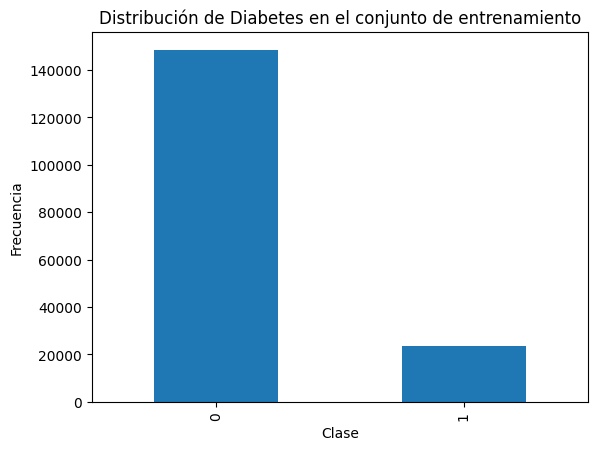

In [5]:
y_train.value_counts().plot(kind='bar')

plt.title("Distribución de Diabetes en el conjunto de entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

El gráfico muestra la **distribución de la variable objetivo (diabetes)** en el conjunto de entrenamiento, evidenciando un **marcado desbalance entre las clases**. La clase **0 (no diabetes)** concentra la mayoría de las observaciones, con más de 140.000 registros, mientras que la clase **1 (diabetes)** apenas supera los 20.000 casos. Esta diferencia significativa implica que los modelos de clasificación podrían inclinarse hacia la clase mayoritaria, reduciendo su capacidad para detectar correctamente los casos positivos. Por ello, resulta necesario aplicar **técnicas de balanceo de clases** que permitan mejorar la representación de la clase minoritaria y, en consecuencia, el desempeño del modelo en términos de *recall* y *F1-score*.


In [6]:
categorical_idx = [X.columns.get_loc(col) for col in cat_cols]

In [7]:
categorical_idx 

[0, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 22, 23]

## **Balance de variable objetivo con ``SMOTENC``**

Para abordar el desbalance observado en la variable objetivo, se aplicó la técnica **SMOTENC (Synthetic Minority Over-sampling Technique for Nominal and Continuous variables)**.  
A diferencia del SMOTE tradicional, que solo funciona con variables numéricas, **SMOTENC permite generar nuevas observaciones sintéticas considerando tanto variables continuas como categóricas**, lo cual resulta ideal para conjuntos de datos mixtos como el de este estudio.

El funcionamiento de SMOTENC consiste en **identificar los vecinos más cercanos de cada observación de la clase minoritaria** y, a partir de ellos, crear ejemplos sintéticos intermedios que preservan la estructura y diversidad del conjunto de datos.  
Durante este proceso, las variables categóricas se tratan mediante codificación interna (manteniendo categorías válidas), mientras que las numéricas se interpolan de manera continua.  

De esta forma, el método **incrementa la representación de la clase minoritaria** sin duplicar registros existentes ni alterar la distribución general de las variables, mejorando así la capacidad de los modelos para **aprender patrones representativos de ambas clases**.  
Tras aplicar SMOTENC, la proporción entre clases se equilibra significativamente, permitiendo obtener modelos con mayor sensibilidad (*recall*) y un mejor desempeño general en la detección de casos positivos.


In [8]:
from imblearn.over_sampling import SMOTENC
df_smote = SMOTENC(categorical_features=categorical_idx, random_state=42)

In [9]:
X_train_resampled, y_train_resampled = df_smote.fit_resample(X_train, y_train)

In [10]:
X_train_resampled.shape, y_train_resampled.shape    

((297082, 24), (297082,))

In [11]:
print("Distribución balanceada:\n", y_train_resampled.value_counts())

Distribución balanceada:
 diabetes
1    148541
0    148541
Name: count, dtype: int64


Los datos de Train ya se encuentran balanceados.

In [12]:
X_train_resampled.head(5)

,salud_general,dias_salud_fisica,dias_salud_mental,ultimo_chequeo,actividades_fisicas,horas_sueño,dientes_removidos,ataque_cardiaco,angina,ACV,...,artritis,estado_fumador,uso_cigarroelect,categoria_etnica,categoria_edad,altura_metros,peso_kilos,bmi,bebedor_alcohol,alto_riesgo_ap
0,Good,0.0,0.0,Within past year (anytime less than 12 months ...,No,10.0,None of them,No,Yes,No,...,Yes,Former smoker,Never,White,Age 75 to 79,1.75,103.42,33.67,Yes,No
1,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,No,No,...,No,Former smoker,Never,White,Age 75 to 79,1.70,72.57,25.06,Yes,No
2,Excellent,7.5,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,"6 or more, but not all",Yes,No,No,...,Yes,Current smoker,Stop,White,Age 50 to 54,1.91,72.57,20.00,Yes,No
3,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,1 to 5,No,No,No,...,No,Never smoked,Stop,White,Age 60 to 64,1.88,83.91,23.75,Yes,No
4,Good,1.0,4.0,Within past year (anytime less than 12 months ...,Yes,6.0,None of them,No,No,No,...,No,Never smoked,Never,White,Age 50 to 54,1.78,62.60,19.80,Yes,No


Guardamos los subconjuntos balanceados.

In [13]:
X_train_resampled.to_csv("X_train_resampled.csv", index=False)
y_train_resampled.to_frame().to_csv("y_train_resampled.csv", index=False)   